# Task Assigning — the Standard Task-Assigning Problem in LangGOAP

A Tier 2 tutorial that GOAPifies the standard task-assigning problem.
The original benchmark ships a ``BendableScore`` with one hard
level (no missing skills) and four soft levels (per-priority end
times + makespan).  We use a compact **6 tasks x 3 employees x
4 skills x 4 task types** subset and flatten the multi-level soft
score into a single weighted ``weighted_delay`` resource so
LangGOAP's current `HardSoftScore` covers it:

```
weighted_delay = priority_weight x base_duration x affinity_multiplier
```

- **critical** tasks are weighted 4x, **major** 2x, **minor** 1x ->
  A\* naturally front-loads high-priority work.
- **affinity** is a duration multiplier per (employee, task type)
  pair (`HIGH=1`, `MEDIUM=2`, `LOW=3`) encoding relative fit.
- **skills** are a hard constraint applied at action-build time:
  employees missing the required skill for a task type simply have
  no action to take that task.

This tutorial exercises:

- Skill-filtered action catalogs
- Multi-objective weighted delay minimization via `HardSoftScore`
- Fluent goal construction through `ConstraintBuilder` (the
  ConstraintBuilder fluent API)
- Per-employee workload caps as soft load-balance signals
- LLM-driven skill matching via the NL goal interpreter

In [1]:
import logging

# The hard-infeasibility demo further down deliberately triggers the
# CSP's "all alternatives infeasible" advisory — silence the warning.
logging.getLogger("langgoap").setLevel(logging.ERROR)

from langgoap import CSPStatus, GoapGraph
from langgoap.planner.pipeline import plan as pipeline_plan
from langgoap.state import PlanningState
from tutorial_examples.data.task_assigning_instance import (
    AFFINITY,
    EMPLOYEES,
    PRIORITY_WEIGHT,
    TASK_TYPE_BY_NAME,
    TASKS,
)
from tutorial_examples.task_assigning import (
    task_assigning_actions,
    task_assigning_goal,
    task_assigning_goal_fluent,
    task_assigning_start,
)

print(f'Employees: {len(EMPLOYEES)}')
for e in EMPLOYEES:
    print(f'  {e.name:6s} skills={sorted(e.skills)}')
print()
print(f'Tasks: {len(TASKS)}')
for t in TASKS:
    tt = TASK_TYPE_BY_NAME[t.task_type]
    print(f'  {t.name}  {t.task_type:<14s} customer={t.customer:<6s} priority={t.priority:<8s} base={tt.base_duration_hours}h  requires={tt.required_skill}')

Employees: 3
  alice  skills=['problem_solving', 'risk_management', 'strategic_planning']
  bob    skills=['creative_thinking', 'problem_solving']
  carol  skills=['creative_thinking', 'risk_management', 'strategic_planning']

Tasks: 6
  t1  sales_strategy customer=steel  priority=critical base=4h  requires=strategic_planning
  t2  compliance     customer=paper  priority=major    base=3h  requires=risk_management
  t3  brand_story    customer=stone  priority=critical base=5h  requires=creative_thinking
  t4  root_cause     customer=wood   priority=major    base=4h  requires=problem_solving
  t5  compliance     customer=steel  priority=minor    base=3h  requires=risk_management
  t6  root_cause     customer=paper  priority=minor    base=4h  requires=problem_solving


## 1. The affinity matrix

Each `(employee, task_type)` cell is the duration multiplier for
that pair.  Blank cells mean the employee is unqualified (hard
constraint — no action emitted).  `1` means "natural fit", `3`
means "can do it but takes three times longer".

In [2]:
task_type_names = [tt for tt in TASK_TYPE_BY_NAME]
header = f"{'employee':<8}" + ''.join(f'{tt:>18s}' for tt in task_type_names)
print(header)
print('-' * len(header))
for e in EMPLOYEES:
    row = f'{e.name:<8}'
    for tt_name in task_type_names:
        tt = TASK_TYPE_BY_NAME[tt_name]
        if tt.required_skill not in e.skills:
            row += f'{"—":>18s}'
        else:
            mult = AFFINITY.get((e.name, tt_name), '—')
            row += f'{mult!s:>18s}'
    print(row)
print()
print(f'Priority weights: {PRIORITY_WEIGHT}')

employee    sales_strategy        compliance       brand_story        root_cause
--------------------------------------------------------------------------------
alice                    1                 2                 —                 3
bob                      —                 —                 1                 1
carol                    3                 1                 2                 —

Priority weights: {'critical': 4, 'major': 2, 'minor': 1}


## 2. Action catalog — skill filter at build time

`task_assigning_actions()` builds one `ActionSpec` per qualified
`(employee, task)` pair.  Each action carries two resources:

- `weighted_delay` (plan-wide) — the cost scalar CSP minimizes
- `workload_<employee>` — effective hours the employee is carrying;
  used for per-employee load balancing

Unqualified pairs never appear: bob cannot do `sales_strategy`
(needs strategic_planning), carol cannot do `root_cause` (needs
problem_solving), alice cannot do `brand_story` (needs creative
thinking), and so on.

In [3]:
actions = task_assigning_actions()
print(f'Total legal actions: {len(actions)}\n')
for a in sorted(actions, key=lambda x: x.name):
    wd = a.resources['weighted_delay']
    emp = a.name.split('_')[1]
    wl = a.resources[f'workload_{emp}']
    print(f'  {a.name:<22s} cost={a.cost:<4.0f} weighted_delay={wd:<4.0f} workload_hours={wl:.0f}')

Total legal actions: 12

  assign_alice_to_t1     cost=16   weighted_delay=16   workload_hours=4
  assign_alice_to_t2     cost=12   weighted_delay=12   workload_hours=6
  assign_alice_to_t4     cost=24   weighted_delay=24   workload_hours=12
  assign_alice_to_t5     cost=6    weighted_delay=6    workload_hours=6
  assign_alice_to_t6     cost=12   weighted_delay=12   workload_hours=12
  assign_bob_to_t3       cost=20   weighted_delay=20   workload_hours=5
  assign_bob_to_t4       cost=8    weighted_delay=8    workload_hours=4
  assign_bob_to_t6       cost=4    weighted_delay=4    workload_hours=4
  assign_carol_to_t1     cost=48   weighted_delay=48   workload_hours=12
  assign_carol_to_t2     cost=6    weighted_delay=6    workload_hours=3
  assign_carol_to_t3     cost=40   weighted_delay=40   workload_hours=10
  assign_carol_to_t5     cost=3    weighted_delay=3    workload_hours=3


### GOAP Execution Graph

The planner discovers a plan, the executor runs each action, and the
observer checks progress — replanning automatically if something fails.

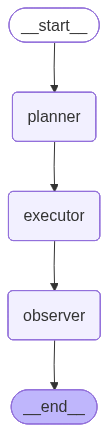

In [4]:
from IPython.display import Image, display

graph = GoapGraph(actions=actions)
display(Image(graph.compile().get_graph().draw_mermaid_png()))

## 3. Solve the cheapest assignment

The default goal asks for every task to be assigned (every
`task_<name>_done` condition satisfied) and attaches a
`weighted_delay → MINIMIZE` objective so the plan routes through
CSP and receives a `HardSoftScore`.

A\* picks the best employee for each task: alice gets the one
`sales_strategy` (her HIGH-affinity task), bob gets both
`root_cause` tickets plus the critical `brand_story`, and carol
takes both `compliance` tickets.  Total weighted delay = **57**.

In [5]:
plan_obj = pipeline_plan(
    PlanningState.from_dict(task_assigning_start()),
    task_assigning_goal(),
    actions,
)

print(f'CSP status:          {plan_obj.metadata.csp.status.value}')
print(f'Total weighted delay: {plan_obj.total_cost}')
print()
print('Assignments (by employee):')
per_emp: dict[str, list[str]] = {e.name: [] for e in EMPLOYEES}
for step in plan_obj.actions:
    _, emp, _, task = step.name.split('_', 3)
    per_emp[emp].append(task)
for emp, tasks in per_emp.items():
    print(f'  {emp}: {", ".join(tasks) if tasks else "(idle)"}')

CSP status:          feasible
Total weighted delay: 57.0

Assignments (by employee):
  alice: t1
  bob: t6, t4, t3
  carol: t5, t2


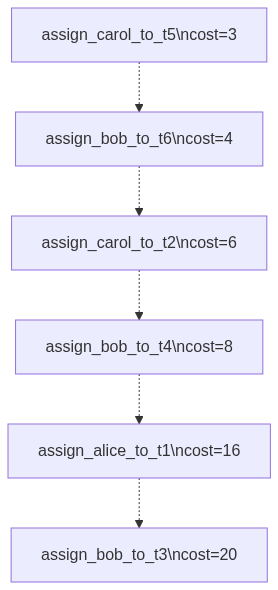

In [6]:
from langchain_core.runnables.graph_mermaid import draw_mermaid_png as _draw_png
from langgoap.viz.mermaid import render_mermaid

display(Image(_draw_png(render_mermaid(plan_obj))))

## 4. HardSoftScore decomposition

With a `weighted_delay → MINIMIZE` objective the pipeline replaces
the pure-A\* `SimpleScore` with a `HardSoftScore` whose `soft`
component mirrors the negated objective.  The per-employee
workloads show bob is carrying 13h while alice only works 4h —
the next cell drives a load rebalance via a soft cap.

In [7]:
print(f'plan.score        = {plan_obj.score}')
print(f'score.is_feasible = {plan_obj.score.is_feasible()}')
print(f'score.value       = {plan_obj.score.value}  (scalar for logging)')
print()
print('Per-employee workload (hours):')
for u in plan_obj.metadata.csp.resource_usage:
    if u.key.startswith('workload_'):
        emp = u.key.removeprefix('workload_')
        print(f'  {emp:<6s} {u.total:>4.0f}h  (level={u.level})')

plan.score        = HardSoftScore(hard=0, soft=-57)
score.is_feasible = True
score.value       = -57.0  (scalar for logging)

Per-employee workload (hours):
  carol     6h  (level=info)
  bob      13h  (level=info)
  alice     4h  (level=info)


## 5. `ConstraintBuilder` — the fluent constraint-provider API

`task_assigning_goal_fluent()` constructs the same goal via the
fluent `ConstraintBuilder`, following the penalize/reward convention
used in constraint-provider DSLs:

```python
ConstraintBuilder.build(
    ConstraintBuilder.for_plan()
        .sum_resource('weighted_delay')
        .minimize()
        .as_objective('weighted_delay'),
    ConstraintBuilder.for_plan()
        .sum_resource('workload_alice')
        .bounded(max=10.0)
        .penalize(level='soft', weight=1.0)
        .as_constraint('workload_alice'),
    # ... one chain per employee
)
```

The result is wired into a `GoalSpec` via `from_builder()` and
produces an identical plan.

In [8]:
fluent_goal = task_assigning_goal_fluent()
hand_goal = task_assigning_goal()

print('hand-built objectives :', dict(hand_goal.objectives or {}))
print('fluent-built objectives:', dict(fluent_goal.objectives or {}))
print()

fluent_plan = pipeline_plan(
    PlanningState.from_dict(task_assigning_start()),
    fluent_goal,
    actions,
)
print(f'fluent score: {fluent_plan.score}')
print(f'hand score  : {plan_obj.score}')
print(f'identical?  : {set(fluent_plan.action_names) == set(plan_obj.action_names)}')

hand-built objectives : {'weighted_delay': <ObjectiveDirection.MINIMIZE: 'minimize'>}
fluent-built objectives: {'weighted_delay': <ObjectiveDirection.MINIMIZE: 'minimize'>}

fluent score: HardSoftScore(hard=0, soft=-57)
hand score  : HardSoftScore(hard=0, soft=-57)
identical?  : True


## 6. Soft workload cap — load balance as a penalty

Adding a per-employee soft cap of **8 hours** highlights bob's
overload without kicking the plan out of the feasible set.  The
overflow (`13 - 8 = 5`) is subtracted from the soft score:

```
soft = -weighted_delay(57) - bob_overflow(5) = -62
```

In [9]:
soft_plan = pipeline_plan(
    PlanningState.from_dict(task_assigning_start()),
    task_assigning_goal(max_workload_per_employee=8.0, max_workload_level='soft'),
    actions,
)

print(f'CSP status: {soft_plan.metadata.csp.status.value}')
print(f'Score     : {soft_plan.score}')
print()
for u in soft_plan.metadata.csp.resource_usage:
    if u.key.startswith('workload_'):
        marker = '✓' if u.satisfied else '✗'
        print(f'  {marker} {u.key:<18s} {u.total:>4.0f}h / 8h cap  level={u.level}')

CSP status: feasible
Score     : HardSoftScore(hard=0, soft=-62)

  ✓ workload_alice        4h / 8h cap  level=soft
  ✗ workload_bob         13h / 8h cap  level=soft
  ✓ workload_carol        6h / 8h cap  level=soft


## 7. Hard workload cap → CSPStatus.INFEASIBLE

Flipping the same cap to `level="hard"` makes bob's 13h workload
fatal: the pipeline enumerates alternatives (single-blacklist) but
none of them rebalance enough to bring every employee under 8h, so
the status flips to `INFEASIBLE` and `hard` records the overflow.

In [10]:
hard_plan = pipeline_plan(
    PlanningState.from_dict(task_assigning_start()),
    task_assigning_goal(max_workload_per_employee=8.0, max_workload_level='hard'),
    actions,
)

print(f'CSP status: {hard_plan.metadata.csp.status.value}')
print(f'Score     : {hard_plan.score}')
print(f'Feasible? : {hard_plan.score.is_feasible()}')

CSP status: infeasible
Score     : HardSoftScore(hard=-5, soft=-57)
Feasible? : False


## 8. Natural-language intake

The NL interpreter turns a free-text ticket-routing request into
the same `GoalSpec` we constructed by hand.  In production pass an
`OpenAI`, `Anthropic` or `Google` chat model; here we use a tiny
`FakeStructuredModel` that returns a canned `InterpretedGoal` so
the tutorial stays offline.

In [11]:
from langgoap import (
    GoalInterpreter,
    InterpretedConstraint,
    InterpretedGoal,
    InterpretedObjective,
)
from langgoap.testing import FakeStructuredModel

interpreted = InterpretedGoal(
    conditions={f'task_{t.name}_done': True for t in TASKS},
    constraints=[
        InterpretedConstraint(key='workload_alice', max=10.0, level='soft'),
        InterpretedConstraint(key='workload_bob', max=10.0, level='soft'),
        InterpretedConstraint(key='workload_carol', max=10.0, level='soft'),
    ],
    objectives=[InterpretedObjective(metric='weighted_delay', direction='minimize')],
    reasoning=(
        "Assign every task; prefer the lowest weighted delay; "
        "'ideally' no one works more than 10 hours → soft cap."
    ),
)

llm = FakeStructuredModel(response=interpreted)
interpreter = GoalInterpreter(llm=llm, actions=actions)

nl_goal = interpreter.interpret(
    'Route every ticket to the best-fit team member; '
    'ideally nobody carries more than ten hours of work.'
)

print('Interpreted reasoning:', interpreted.reasoning)
print()
print('Constraints emitted:')
for c in nl_goal.constraints:
    print(f'  {c.key} <= {c.max} (level={c.level})')
print()
print('Objectives emitted:')
for k, v in (nl_goal.objectives or {}).items():
    print(f'  {k}: {v.value}')

Interpreted reasoning: Assign every task; prefer the lowest weighted delay; 'ideally' no one works more than 10 hours → soft cap.

Constraints emitted:
  workload_alice <= 10.0 (level=soft)
  workload_bob <= 10.0 (level=soft)
  workload_carol <= 10.0 (level=soft)

Objectives emitted:
  weighted_delay: minimize


## 9. End-to-end via `GoapGraph.invoke_nl()`

The one-liner `invoke_nl()` composes the three stages: the LLM
interprets the request, the A\* + CSP pipeline finds the cheapest
feasible assignment, and the LangGraph executor runs every action
against a mutable world state copy until all tasks are done.

In [12]:
result = GoapGraph(actions=actions).invoke_nl(
    'Route every ticket to the best-fit team member; '
    'ideally nobody carries more than ten hours of work.',
    llm=llm,
    world_state=task_assigning_start(),
)

print(f'status: {result["status"]}')
print()
print('Final world state:')
for t in TASKS:
    key = f'task_{t.name}_done'
    print(f'  {key:<20s} {result["world_state"][key]}')

status: goal_achieved

Final world state:
  task_t1_done         True
  task_t2_done         True
  task_t3_done         True
  task_t4_done         True
  task_t5_done         True
  task_t6_done         True


## Summary

- **Skills are filtered, affinities are costed.** Hard constraints
  become action-catalog exclusions; soft preferences become cost
  multipliers A\* can reason about directly.
- **Priority weighting is just another multiplier.** Collapsing
  the multi-level `BendableScore` into a single weighted
  delay keeps the pipeline on `HardSoftScore` while still
  front-loading critical tickets.
- **Per-entity resources generalize to any load-balance problem.**
  The per-employee `workload_<name>` pattern mirrors the per-server
  `cpu_<name>` pattern from the cloud balancing tutorial — LangGOAP
  treats both uniformly.
- **`ConstraintBuilder` is the constraint-provider analogue.**
  Fluent chains terminate in either `.as_constraint(name)` or
  `.as_objective(name)`; `GoalSpec.from_builder()` wires them into
  the same two fields the hand-rolled constructor populates.
- **Soft caps shine where alternatives are limited.** LangGOAP's
  single-blacklist alternative enumeration struggles to *find* a
  rebalanced assignment under tight hard caps, but soft caps are
  cheap: they keep the greedy plan feasible and pay a transparent
  penalty on the score instead.

Next tutorials cover SQL query agents with `effect_validator`-
driven replanning and vulnerability scanners that chain sensor
state into the GOAP loop.